/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


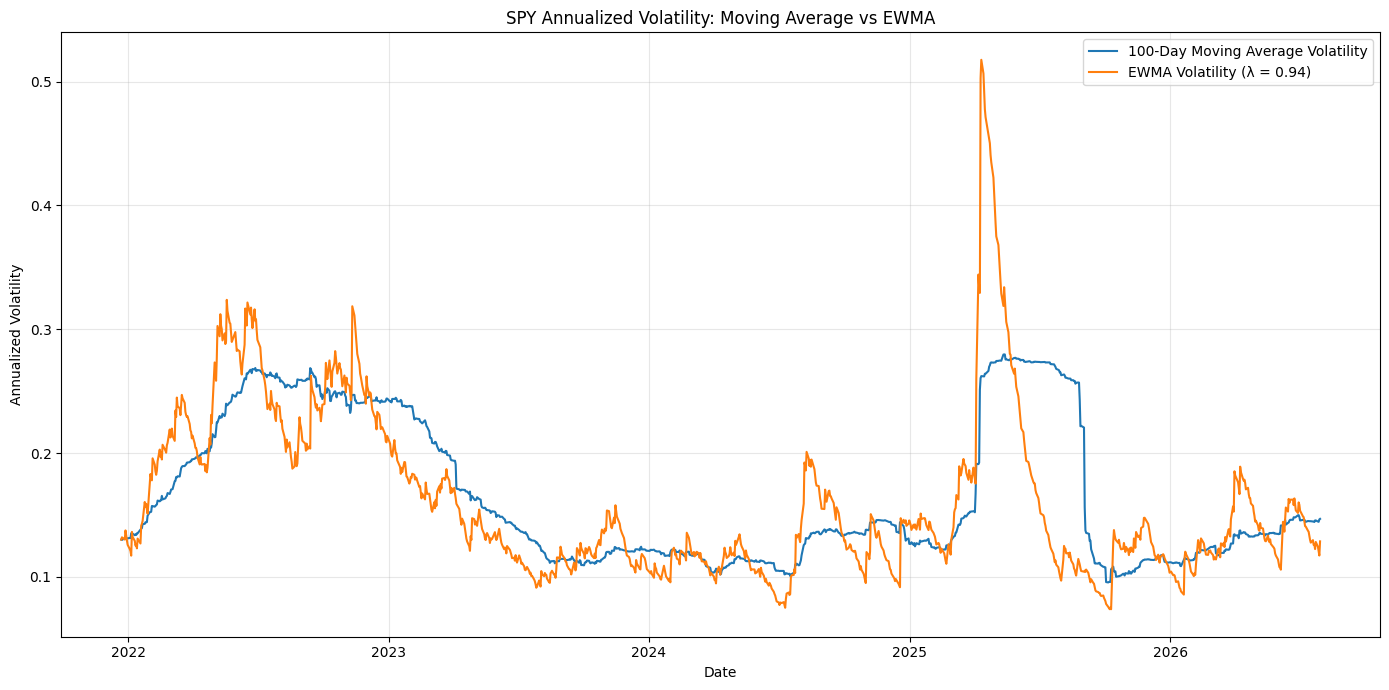

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Download SPY data
# -------------------------------------------------
start_date = "2021-08-01"
end_date = "2026-07-31"  

spy = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

# Use adjusted close to account for dividends/splits
price = spy["Adj Close"]

# If yfinance returns a one-column DataFrame, convert it to Series
if isinstance(price, pd.DataFrame):
    price = price.iloc[:, 0]

# -------------------------------------------------
# 2. Calculate daily log returns
# -------------------------------------------------
log_returns = np.log(price / price.shift(1)).dropna()

# -------------------------------------------------
# 3. Moving Average volatility
#    Look-back period n = 100 days
# -------------------------------------------------
n = 100

# Daily variance estimate using the past 100 observations
ma_variance = log_returns.rolling(window=n).var(ddof=1)

# Annualized volatility:
# sigma_annual = sigma_daily / sqrt(Delta)
# where Delta = 1/252
delta = 1 / 252

ma_vol_annual = np.sqrt(ma_variance / delta)

# Equivalent:
# ma_vol_annual = np.sqrt(ma_variance * 252)


# -------------------------------------------------
# 4. EWMA volatility
#    lambda = 0.94
# -------------------------------------------------
lam = 0.94

# Create an empty Series for EWMA variance
ewma_variance = pd.Series(
    index=log_returns.index,
    dtype=float
)

# Initial variance = sample variance of first 100 daily log returns
initial_variance = log_returns.iloc[:n].var(ddof=1)

# Start the EWMA estimate at day 100
ewma_variance.iloc[n - 1] = initial_variance

# Recursive EWMA variance:
# sigma_t^2 = lambda * sigma_{t-1}^2
#             + (1-lambda) * r_{t-1}^2
for t in range(n, len(log_returns)):
    ewma_variance.iloc[t] = (
        lam * ewma_variance.iloc[t - 1]
        + (1 - lam) * log_returns.iloc[t - 1] ** 2
    )

# Annualize EWMA volatility
ewma_vol_annual = np.sqrt(ewma_variance / delta)

# -------------------------------------------------
# 5. Plot both volatility estimates
# -------------------------------------------------
plt.figure(figsize=(14, 7))

plt.plot(
    ma_vol_annual.index,
    ma_vol_annual,
    label="100-Day Moving Average Volatility",
    linewidth=1.5
)

plt.plot(
    ewma_vol_annual.index,
    ewma_vol_annual,
    label="EWMA Volatility (λ = 0.94)",
    linewidth=1.5
)

plt.title("SPY Annualized Volatility: Moving Average vs EWMA")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    SPY   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -277.723
Distribution:                  Normal   AIC:                           563.445
Method:            Maximum Likelihood   BIC:                           577.515
                                        No. Observations:                  249
Date:                Sun, Sep 20 2026   Df Residuals:                      248
Time:                        18:54:40   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0995  4.465e-02      2.227  2.594e-02 [1.193e-0

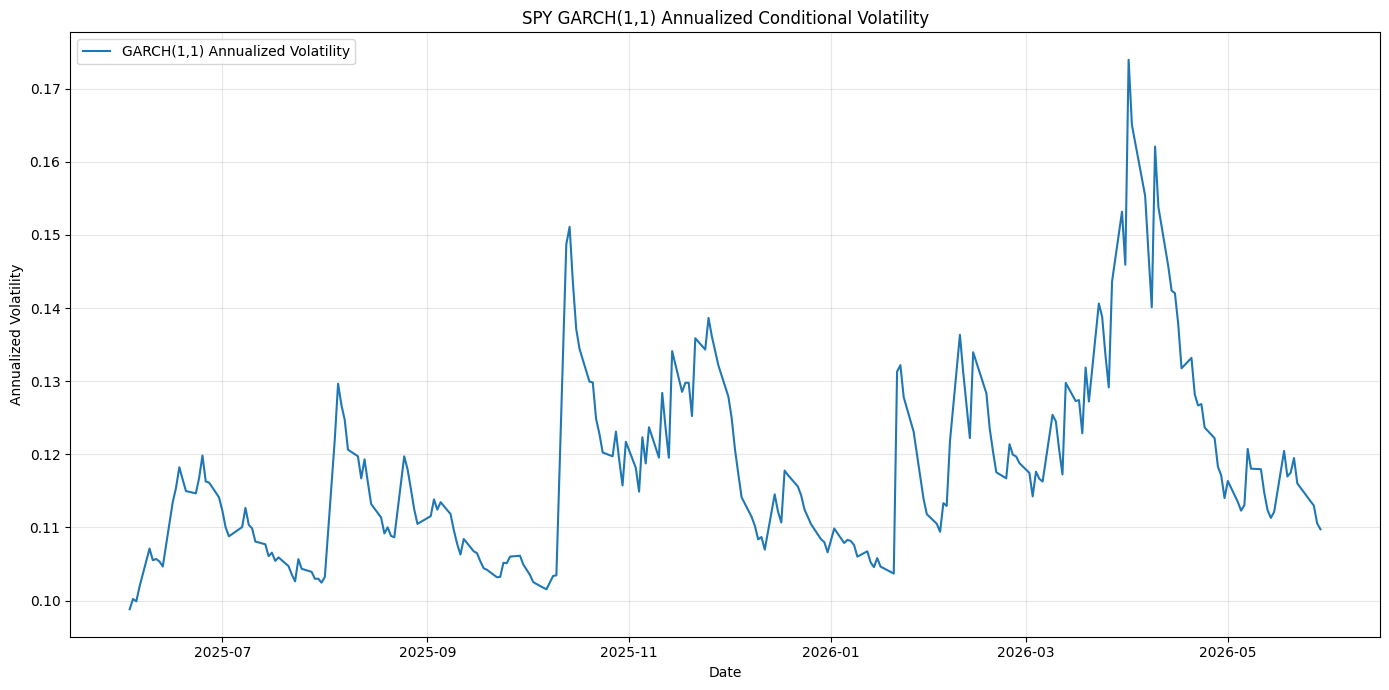

In [2]:
from arch import arch_model

# -------------------------------------------------
# 1. Download SPY closing prices
# -------------------------------------------------
start_date = "2025-06-01"
end_date = "2026-06-01"   

spy = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

# Use closing price as requested
price = spy["Close"]

# Convert to Series if yfinance returns a DataFrame
if isinstance(price, pd.DataFrame):
    price = price.iloc[:, 0]


# -------------------------------------------------
# 2. Calculate daily log returns
# -------------------------------------------------
log_returns = np.log(price / price.shift(1)).dropna()

# arch package works better when returns are in percentage terms
returns_pct = log_returns * 100


# -------------------------------------------------
# 3. Fit GARCH(1,1)
# -------------------------------------------------
# Mean = Constant
# Variance model:
# sigma_t^2 = omega + alpha * epsilon_(t-1)^2
#             + beta * sigma_(t-1)^2

garch_model = arch_model(
    returns_pct,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_result = garch_model.fit(disp="off")


# -------------------------------------------------
# 4. Display estimation results
# -------------------------------------------------
print(garch_result.summary())


# -------------------------------------------------
# 5. Extract fitted conditional volatility
# -------------------------------------------------
conditional_vol_daily = garch_result.conditional_volatility

# Convert from percentage back to decimal
conditional_vol_daily = conditional_vol_daily / 100

# Annualize using Delta = 1/252
delta = 1 / 252
conditional_vol_annual = conditional_vol_daily / np.sqrt(delta)


# -------------------------------------------------
# 6. Plot annualized GARCH volatility
# -------------------------------------------------
plt.figure(figsize=(14, 7))

plt.plot(
    conditional_vol_annual.index,
    conditional_vol_annual,
    label="GARCH(1,1) Annualized Volatility",
    linewidth=1.5
)

plt.title("SPY GARCH(1,1) Annualized Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Number of forecast days: 42


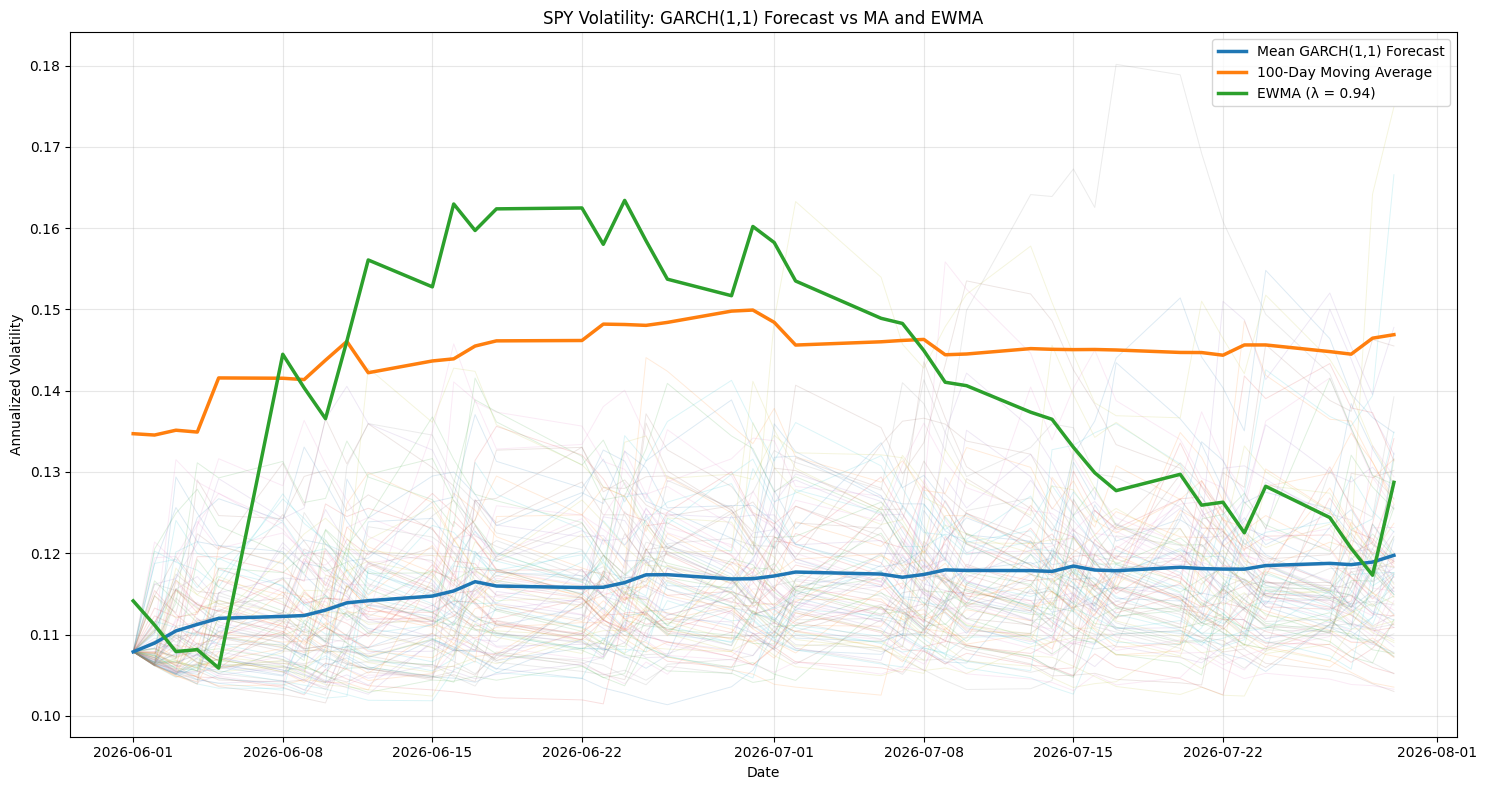

In [3]:
# -------------------------------------------------
# Forecast GARCH(1,1) volatility from
# 06/01/2026 to 07/30/2026 using M = 100 paths
# -------------------------------------------------

# Extract fitted parameters from the existing GARCH model
omega = garch_result.params["omega"]
alpha = garch_result.params["alpha[1]"]
beta = garch_result.params["beta[1]"]

# -------------------------------------------------
# Forecast period
# -------------------------------------------------

# Use MA dates because the MA dataset already contains
# observations through 07/30/2026
ma_forecast = ma_vol_annual.loc[
    "2026-06-01":"2026-07-30"
]

ewma_forecast = ewma_vol_annual.loc[
    "2026-06-01":"2026-07-30"
]

forecast_dates = ma_forecast.index

H = len(forecast_dates)
M = 100

print("Number of forecast days:", H)


# -------------------------------------------------
# Initial values from the fitted GARCH model
# -------------------------------------------------

last_variance = garch_result.conditional_volatility.iloc[-1] ** 2
last_epsilon = garch_result.resid.iloc[-1]


# -------------------------------------------------
# Simulate 100 GARCH volatility paths
# -------------------------------------------------

np.random.seed(42)

garch_paths = np.zeros((H, M))

for m in range(M):

    # First forecast variance
    variance = (
        omega
        + alpha * last_epsilon ** 2
        + beta * last_variance
    )

    for h in range(H):

        # Store forecast volatility
        garch_paths[h, m] = np.sqrt(variance)

        # Simulate next return shock
        z = np.random.normal(0, 1)

        epsilon = np.sqrt(variance) * z

        # Update variance
        variance = (
            omega
            + alpha * epsilon ** 2
            + beta * variance
        )


# -------------------------------------------------
# Annualize GARCH volatility
# -------------------------------------------------

# GARCH was fitted using percentage returns,
# so divide by 100 before annualizing
garch_paths_annual = (
    garch_paths / 100
) * np.sqrt(252)


# -------------------------------------------------
# Select MA and EWMA volatility
# over the same forecast period
# -------------------------------------------------

ma_forecast = ma_vol_annual.loc[
    "2026-06-01":"2026-07-30"
]

ewma_forecast = ewma_vol_annual.loc[
    "2026-06-01":"2026-07-30"
]


# Mean of the 100 simulated GARCH paths
mean_garch_path = garch_paths_annual.mean(axis=1)


# -------------------------------------------------
# Plot comparison
# -------------------------------------------------

plt.figure(figsize=(15, 8))

# Plot 100 simulated GARCH paths
for m in range(M):
    plt.plot(
        forecast_dates,
        garch_paths_annual[:, m],
        linewidth=0.7,
        alpha=0.15
    )

# Mean GARCH path
plt.plot(
    forecast_dates,
    mean_garch_path,
    linewidth=2.5,
    label="Mean GARCH(1,1) Forecast"
)

# MA volatility
plt.plot(
    ma_forecast.index,
    ma_forecast,
    linewidth=2.5,
    label="100-Day Moving Average"
)

# EWMA volatility
plt.plot(
    ewma_forecast.index,
    ewma_forecast,
    linewidth=2.5,
    label="EWMA (λ = 0.94)"
)

plt.title(
    "SPY Volatility: GARCH(1,1) Forecast vs MA and EWMA"
)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()